# Out of Focus Blur

## Learning Outcomes

In this reading assignment, you'll learn about,

* Image blurring
* Out-of-focus blur
* Image deblurring

## Introduction

Images taken by a camera, in general, suffer from a certain level of degraded representation of the original object during the process of image formation.  Blur is a  common,  unwanted artifact associated with image formation.Blurring is a process that can happen due to numerous reasons, such as atmospheric distortions, entity motion, optical irregularities, movement, etc.

When a image is taken by the camera, there may be some points which are in focus while others are not. This is out-of-focus blur. Due to the presence of noise, the image not only gets blurred but also suffers from degradation.

Mathematically,  image  degradation  due  to  blurring  and  noise  can  be  modelled  by  a  linear system as follows:

$$g(x,y) = Af(x,y)+ n(x,y) ---(i)$$


where

- $(x, y)$ represents spatial coordinates,
- $g(x, y)$ is the acquired image with blur and noise,
- $A$ is the blurring matrix defined by a certain point spread function (PSF),
- $f (x, y)$ is a true image and
- $n(x, y)$  is noise.

In terms of PSF $eqn(i) $ is rewritten as:

$$g(x,y) = K(x,y) \bigotimes  f(x,y)+ n(x,y) ---(i)$$

where,

$K(x,y)$ is PSF that causes image bluring and $\bigotimes$ is 2-D convolution.


We know out-of-focus blur degrades the image. Gaussian blur is one of the ways to induce out-of-focus blur.



**Gaussian Blur**

Gaussian blurring or filtering is a linear filtering technique that uses gaussian kernel. These filters are used to remove noise and throw way the finer details that may act as noise in further image processing. In any case you are focused on extracting a coarser detail and feature at a higher abstraction, then you can simply use this filtering method. The mathematical formulation of gaussian kernel is given in the previous chapter. Gaussian blur can induce out-of-focus blur.

You can checkout this [link](https://upload.wikimedia.org/wikipedia/commons/thumb/6/62/Cappadocia_Gaussian_Blur.svg/300px-Cappadocia_Gaussian_Blur.svg.png) for visualizing the blurring using the Gaussian Blur.
<!--
<figure>
<center>
<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/6/62/Cappadocia_Gaussian_Blur.svg/300px-Cappadocia_Gaussian_Blur.svg.png' />


<Figcaption> Figure 1: Blurring using Gaussian filter(For different standard deviation value) (src: <a href='https://commons.wikimedia.org/wiki/File:Cappadocia_Gaussian_Blur.svg'>link</a>)  </Figcaption>
</center>
</figure> -->

We can see in the figure above the implementation of gaussian filter to induce  blur in the image. As the standard deviation increases, the blurring effect becomes more pronounced.

Out-of-focus image deblurring is the technique of removing the out-of-focus blur in the image. It is essentially the inverse process of blurring. Some of the techniques of image deblurring are given below.

**Pseudo-inverse filtering**

In this case, we use a pseudo-linear filter which acts as the inverse of the blurring kernel. It is a type of linear filter and one of the simplest image deblurring techniques. But in practise, it is very inefficient because the inverse effect even amplifies the noise present in the acquired image, making the deblurred image even more worse.

<br/>

**Regularization method**

Regularization method is used to remove noise amplification in the final image. Regularization  enforces certain regularity conditions on the solution. The regularization parameter $\mu$ has an effect on the quality of the output image and increasing this parameter can even increase the relative image restoration error after a certaain mark. Hence, this method is used in conjunction with other methods to get a perfect result.

<br />

**Conjugate Gradient**

In this method, we use an iterative method. It is more faster and computationally efficient than regularization method.


## Implememtation

Let us try to use gaussian blur to induce blur in an image using openCV

In [ ]:
# Downloading image
!curl -q "https://upload.wikimedia.org/wikipedia/commons/thumb/0/01/Souvenirs_de_L%C3%A9onard_1905_cover_portrait_%28adjusted%29.jpg/445px-Souvenirs_de_L%C3%A9onard_1905_cover_portrait_%28adjusted%29.jpg" -o image.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 47232  100 47232    0     0   334k      0 --:--:-- --:--:-- --:--:--  334k


In [ ]:
#importing required liibrary
import cv2
import matplotlib.pyplot as plt

In [ ]:
#Read image
image = cv2.imread("image.jpg")

Shape of image: (480, 445, 3)


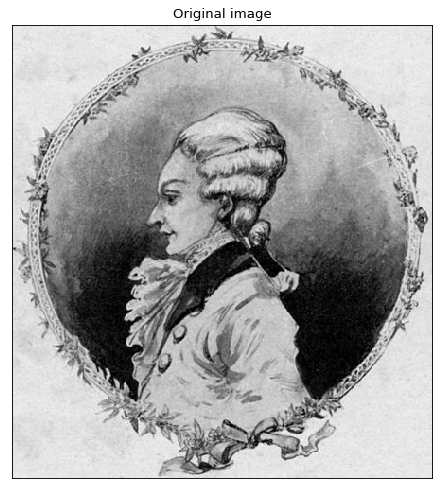

In [ ]:
#Showing image in more nicer form
print(f"Shape of image: {image.shape}")
dpi = 80
margin = 0.05 # (5% of the width/height of the figure...)
xpixels, ypixels = image.shape[0:2]
# Make a figure big enough to accomodate an axis of xpixels by ypixels
# as well as the ticklabels, etc...
figsize = (1 + margin) * ypixels / dpi, (1 + margin) * xpixels / dpi
fig = plt.figure(figsize=figsize, dpi=dpi)
# Make the axis the right size...
ax = fig.add_axes([margin, margin, 1 - 2*margin, 1 - 2*margin])
ax.set_title("Original image")
ax.imshow(image, interpolation='none')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
#Use of gaussian blur with different sigma value
kernel = (5, 5)
blurred1 = cv2.GaussianBlur(image, kernel, sigmaX=5, sigmaY=5)
blurred2 = cv2.GaussianBlur(image, kernel, sigmaX=10, sigmaY=10)
blurred3 = cv2.GaussianBlur(image, kernel, sigmaX=20, sigmaY=20)


Text(0.5, 1.0, 'blurredscale = 2')

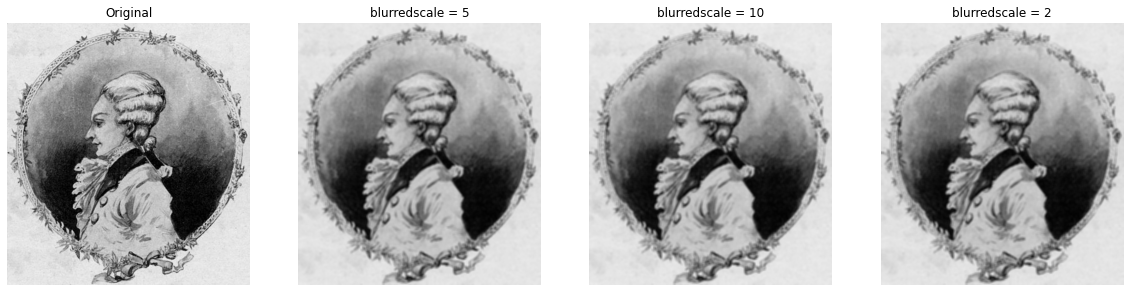

In [ ]:
#Plotting effect of gaussian blur of different sigma value on original image

fig= plt.figure(figsize=(20,20))
a = fig.add_subplot(1,4,1)
plt.axis('off')
plt.imshow(image)
a.set_title('Original')

a = fig.add_subplot(1,4,2)
plt.axis('off')
plt.imshow(blurred1)
a.set_title('blurredscale = 5')

a = fig.add_subplot(1,4,3)
plt.axis('off')
plt.imshow(blurred2)
a.set_title('blurredscale = 10')

a = fig.add_subplot(1,4,4)
plt.axis('off')
plt.imshow(blurred3)
a.set_title('blurredscale = 2')


Here, we can see as the standard deviation increases the image becomes more blurry.

## Key Takeaways

- Image blurring  cause image to degrade.
- In Out-of-focus blur, some parts are in focus while others are not.
- Gaussian blur or filter can produce out-of-focus blur
- Image deblurring means removing the blur in the image.
